# Point density maps in spatialdata-plot

A single Xenium run localises **tens of millions** of transcripts. Plotting each as its own marker is
both infeasibly slow and unreadable — the points pile into a solid blob. `render_points(density=True)`
instead aggregates the points into a 2-D **count density** with datashader and renders that as a
heatmap, so you can see where signal concentrates. By the end you should be able to:

- Turn a huge point cloud into a density map with `density=True`.
- Reshape the intensity mapping with `density_how` (`linear`, `log`, `cbrt`, `eq_hist`).
- Draw a separate density per category by colouring on a categorical column.
- Recognise which parameters density ignores, and why.

We use the full 10x **Xenium** breast-cancer sample (Janesick et al.) from the SpatialData sandbox —
about **43 million** transcripts. It is a ~3.6 GB download, fetched and cached on first use.

## Setup

In [1]:
import pooch
import spatialdata as sd
import spatialdata_plot  # noqa: F401  # registers the .pl accessor

# Fetch the SpatialData-Zarr of the Xenium breast sample (cached after the first run).
url = "https://s3.embl.de/spatialdata/spatialdata-sandbox/xenium_rep1_io_spatialdata_0.7.1.zip"
files = pooch.retrieve(
    url=url,
    known_hash="d463c7e82e212ba87843053c5e07648ba4a233d1bef6f22c2085e7f4f18e0e9f",
    path="data/xenium_rep1",
    processor=pooch.Unzip(extract_dir="xenium_rep1"),
)
zarr_root = next(f.split("data.zarr")[0] + "data.zarr" for f in files if "data.zarr" in f)

sdata = sd.read_zarr(zarr_root)
sdata

Unzipping contents of '/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/examples/data/xenium_rep1/b6ec35e59d527199811ed10d2812e491-xenium_rep1_io_spatialdata_0.7.1.zip' to '/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/examples/data/xenium_rep1/xenium_rep1'


SpatialData object, with associated Zarr store: /Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/examples/data/xenium_rep1/xenium_rep1/data.zarr
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
│     └── 'morphology_mip': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (167780, 2) (2D shapes)
│     └── 'xenium_landmarks': GeoDataFrame shape: (3, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (167780, 313)
with coordinate systems:
    ▸ 'aligned', with elements:
        morphology_focus (Images)
    ▸ 'global', with elements:
        morphology_focus (Images), morphology_mip (Images), transcripts (Points), c

## 1. The overplotting problem

`transcripts` holds ~43 million points — far too many to draw as markers. Even zoomed into a small
2&thinsp;mm&sup2; window the markers already overlap into a solid mass, and the full sample would be
both unreadable and very slow to render.

/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/functools.py:982: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


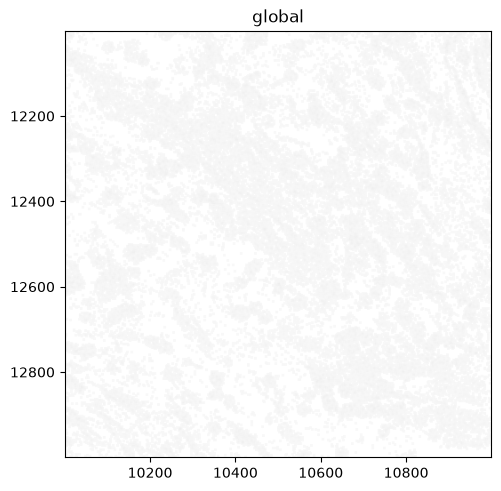

In [2]:
from spatialdata import bounding_box_query

window = bounding_box_query(
    sdata, axes=("x", "y"),
    min_coordinate=[10000, 12000], max_coordinate=[11000, 13000],
    target_coordinate_system="global",
)
window.pl.render_points("transcripts", size=2, alpha=0.4).pl.show()

## 2. A density map — `density=True`

`density=True` bins **all** the points and colours each bin by its count. Dense regions — ducts,
tumour nests — stand out immediately, and the colorbar is a transcript count.

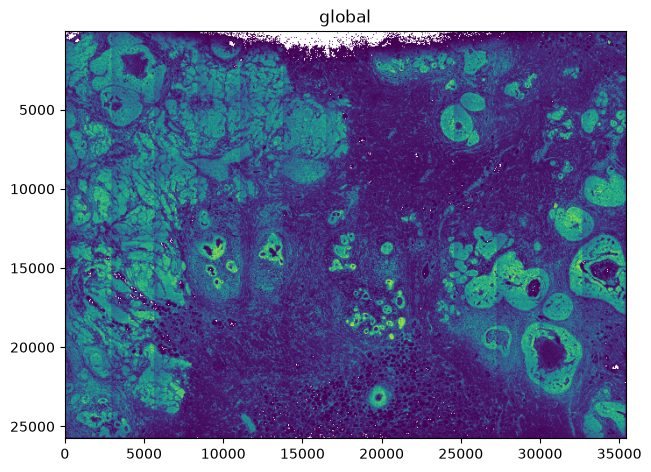

In [3]:
sdata.pl.render_points("transcripts", density=True).pl.show()

## 3. Reshaping the intensity — `density_how`

Counts are heavy-tailed, so a linear mapping buries most of the structure below the few densest bins.
`density_how` controls how counts map to colour: `linear` (a true count axis), `log`/`cbrt` (compress
the range), and `eq_hist` (rank-based histogram equalisation, which reveals the most structure but
drops the count axis).

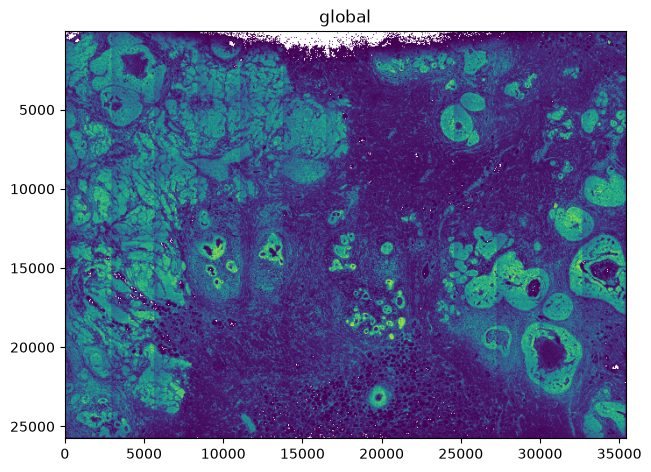

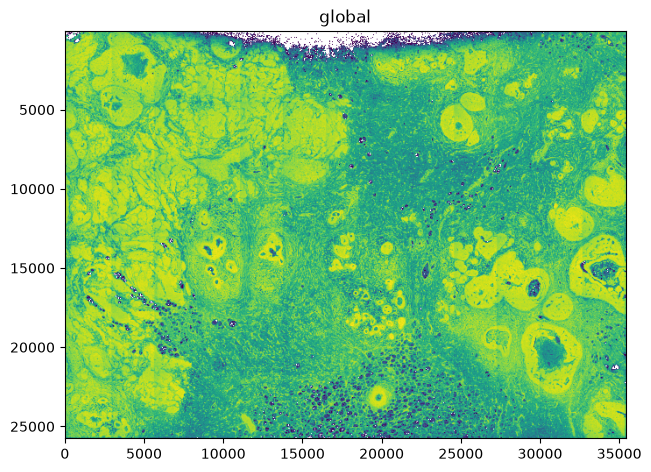

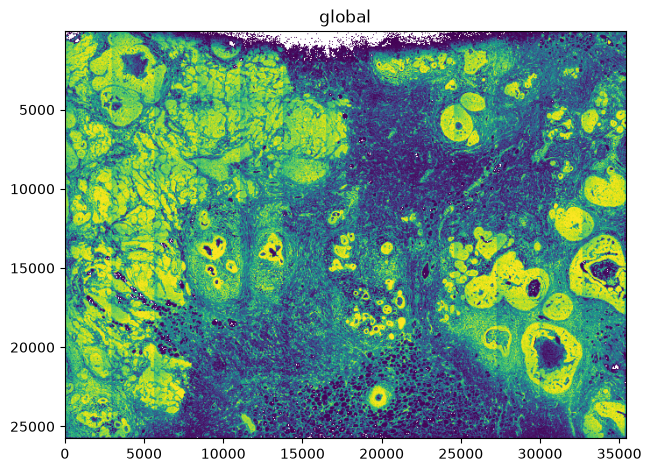

In [4]:
for how in ["linear", "log", "eq_hist"]:
    sdata.pl.render_points("transcripts", density=True, density_how=how).pl.show()

## 4. Per-category density

Colouring by a categorical column draws a **separate density per category** (via `datashader.by`).
Here, three marker genes selected with `groups` — each traces its own spatial distribution.

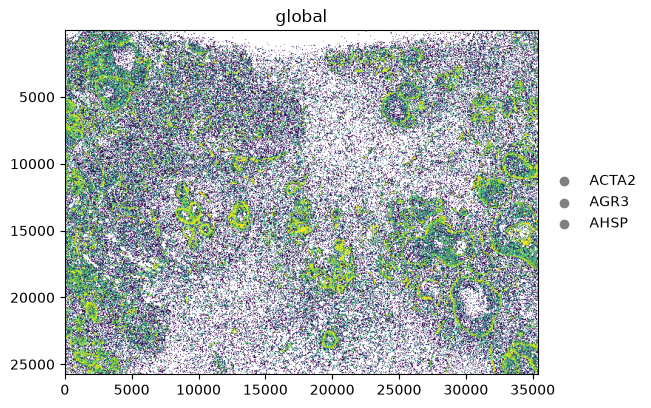

In [5]:
sdata.pl.render_points(
    "transcripts",
    color="feature_name",
    groups=["ACTA2", "AGR3", "AHSP"],
    density=True,
    density_how="eq_hist",
).pl.show()

## 5. What density ignores

Because density aggregates rather than drawing markers, marker-level parameters no longer apply.
Setting them under `density=True` warns and is ignored: `size`, `transfunc`, an explicit
`norm.vmin/vmax`, and `datashader_reduction` (density is always a count). Only `color` (categorical or
`None`) and `density_how` shape the result; a continuous `color` column or a literal colour raises.

/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/spatialdata/_utils.py:278: UserWarning: size is ignored when density=True; spreading would distort the count signal.
  return f(*args, **kwargs)


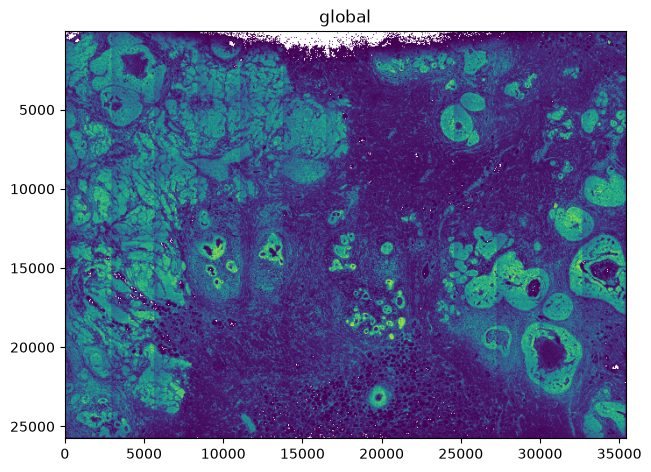

In [6]:
# size is ignored under density (warns), the map is unchanged
sdata.pl.render_points("transcripts", density=True, size=50).pl.show()

## Summary

- `density=True` turns an overplotting point cloud (here ~43 M transcripts) into a datashader **count
  density** heatmap you can actually read.
- `density_how` (`linear`/`log`/`cbrt`/`eq_hist`) reshapes how counts map to colour; `eq_hist`
  surfaces the most structure at the cost of the count axis.
- A categorical `color` draws one density per category; `color=None` gives the overall density.
- Density ignores marker-level parameters (`size`, `transfunc`, `norm` limits,
  `datashader_reduction`) — for those, plot markers or use `method="datashader"` without `density`.

## For reproducibility

In [7]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,datashader,pooch,matplotlib

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.14.1

spatialdata     : 0.7.3
spatialdata_plot: 0.4.1
datashader      : 0.19.1
pooch           : 1.9.0
matplotlib      : 3.11.0

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

